# Task 2: Predictive Analysis Using Machine Learning

## Customer Churn Prediction

###  1. Objective
To build a machine learning classification model that predicts whether a customer is likely to churn based on their demographic, service, and account information.

## 2. Import Required Libraries

The following Python libraries are used in this project for:

- Data manipulation and numerical operations
- Data visualization
- Splitting the dataset into training and testing sets
- Building the machine learning model
- Evaluating model performance

In [2]:
# ============================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================

# Data manipulation and numerical operations
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Machine learning classification model
from sklearn.linear_model import LogisticRegression

# Model evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

## 3. Load the Dataset

In this step, the Telco Customer Churn dataset is loaded into a Pandas DataFrame for further data analysis and machine learning.

In [3]:
# ============================================================
# LOAD THE DATASET
# ============================================================

# Load the Telco Customer Churn CSV file into a DataFrame
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Display the first five rows of the dataset
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 4. Understanding the Dataset

Before performing data cleaning and analysis, we will examine the structure, columns, data types, and basic statistics of the dataset.

In [4]:
# ============================================================
# CHECK THE SHAPE OF THE DATASET
# ============================================================

# Display the number of rows and columns in the dataset
df.shape

(7043, 21)

In [7]:
# Display basic statistical information for numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 5. Data Cleaning

Data cleaning is performed to ensure that the dataset is in a suitable format for analysis and machine learning. In this step, we will check and correct data types where required.

In [9]:
# Check the data type of the TotalCharges column
df['TotalCharges'].dtype

dtype('O')

In [10]:
# Convert the TotalCharges column from object type to numeric type
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [11]:
# Check the updated data type of the TotalCharges column
df['TotalCharges'].dtype

dtype('float64')

In [13]:
# Remove rows where TotalCharges is missing
df = df.dropna(subset=['TotalCharges'])

# Check the shape of the dataset after removing missing values
df.shape

(7032, 21)

In [14]:
# Check missing values in all columns after cleaning
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [15]:
# Display the dataset information after cleaning
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

## 6. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand patterns, relationships, and trends in the customer data before building the machine learning model.

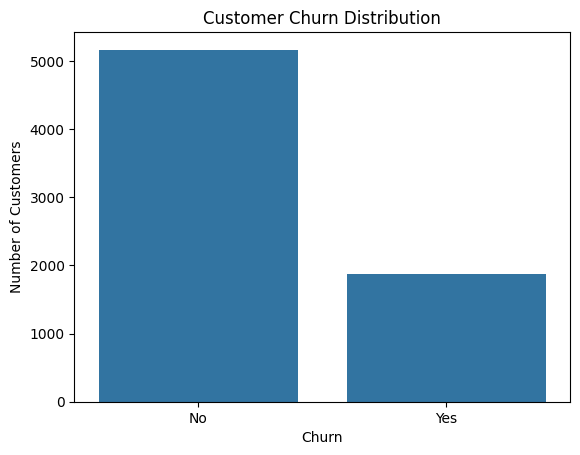

In [46]:
# Create a count plot to visualize churn distribution
sns.countplot(data=df, x='Churn')

# Add chart labels
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

# Display the plot
plt.show()

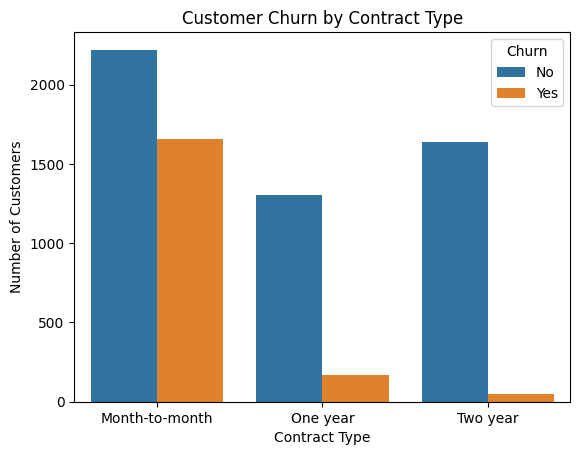

In [19]:
# Visualize churn distribution by contract type
sns.countplot(data=df, x='Contract', hue='Churn')

# Add chart labels
plt.title('Customer Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')

plt.show()

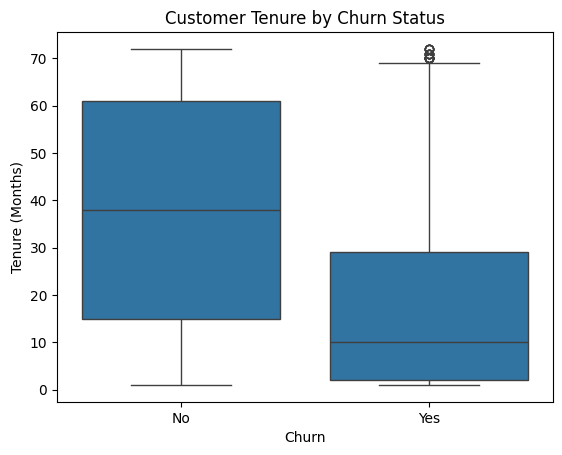

In [20]:
# Compare customer tenure with churn status
sns.boxplot(data=df, x='Churn', y='tenure')

# Add chart labels
plt.title('Customer Tenure by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')

plt.show()

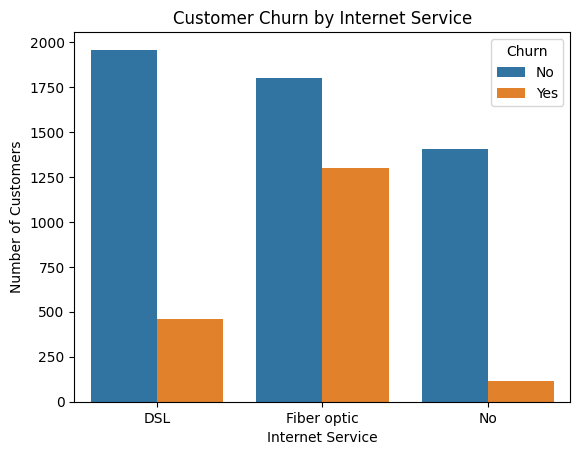

In [22]:
# Visualize churn distribution by internet service type
sns.countplot(data=df, x='InternetService', hue='Churn')

# Add chart labels
plt.title('Customer Churn by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')

plt.show()

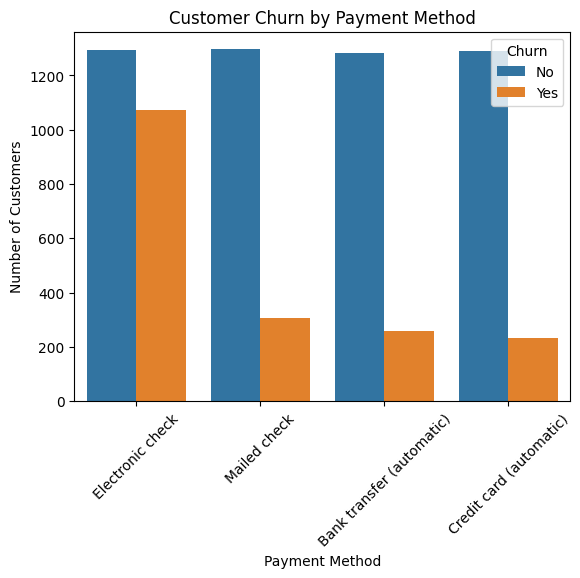

In [23]:
# Visualize churn distribution by payment method
sns.countplot(data=df, x='PaymentMethod', hue='Churn')

# Add chart labels
plt.title('Customer Churn by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

plt.show()

In [25]:
# Check the data types of all columns
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [26]:
# Remove customerID because it is only an identifier
df = df.drop('customerID', axis=1)

# Check the columns after removing it
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [27]:
# X contains the input features
X = df.drop('Churn', axis=1)

# y contains the target variable
y = df['Churn']

# Check their shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7032, 19)
y shape: (7032,)


## 7. Machine Learning Model

The dataset is prepared and a Logistic Regression model is trained to predict customer churn.

In [28]:
# Convert Churn from text to numbers
y = y.map({'No': 0, 'Yes': 1})

# Check the result
y.value_counts()

,count
Churn,
0,5163
1,1869


In [29]:
# Convert categorical columns into numerical columns
X = pd.get_dummies(X, drop_first=True)

# Check the new shape
print("X shape:", X.shape)

X shape: (7032, 30)


In [30]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Check the shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5625, 30)
X_test: (1407, 30)
y_train: (5625,)
y_test: (1407,)


In [52]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on training data and transform it
X_train = scaler.fit_transform(X_train)

# Use the same scaler to transform test data
X_test = scaler.transform(X_test)

# Check the shape after scaling
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (5625, 30)
X_test: (1407, 30)


In [47]:
# Create the Logistic Regression model
model = LogisticRegression(random_state=42)

# Train the model using the training data
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [33]:
# Make predictions on the test data
y_pred = model.predict(X_test)

# Display the first 10 predictions
y_pred[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0])

In [34]:
from sklearn.metrics import accuracy_score

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8038379530916845


In [35]:
from sklearn.metrics import classification_report

# Generate a detailed classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [36]:
from sklearn.metrics import confusion_matrix

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[916 117]
 [159 215]]


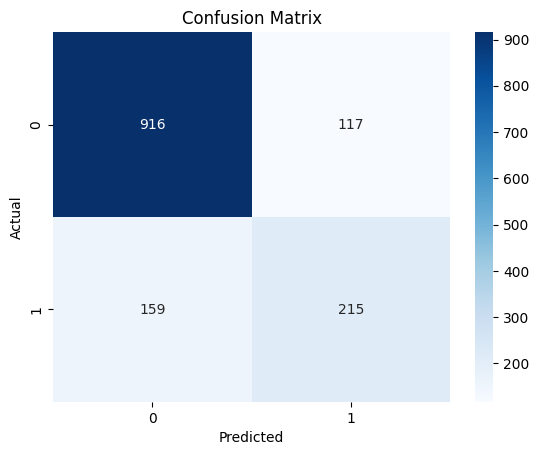

In [37]:
# Visualize the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [38]:
from sklearn.metrics import roc_auc_score

# Calculate ROC-AUC score
y_prob = model.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.8356727976766699


In [45]:
# Get feature coefficients from the Logistic Regression model
feature_importance = pd.Series(
    model.coef_[0],
    index=X.columns
).sort_values(key=abs, ascending=False)

# Display the top 10 most influential features
feature_importance.head(10)

,0
tenure,-1.347613
MonthlyCharges,-0.851551
InternetService_Fiber optic,0.727745
TotalCharges,0.639028
Contract_Two year,-0.602591
Contract_One year,-0.310898
StreamingTV_Yes,0.249702
StreamingMovies_Yes,0.236368
MultipleLines_Yes,0.214359
PaymentMethod_Electronic check,0.181473


## Conclusion

The Logistic Regression model achieved an accuracy of approximately 80.4% and a ROC-AUC score of 0.836. The model shows good ability to distinguish between customers who are likely to churn and those who are not.

The feature analysis shows that tenure, MonthlyCharges, InternetService, TotalCharges, and Contract are among the most influential factors in predicting customer churn.

Overall, the model can be used to identify customers who have a higher likelihood of churning and can help businesses take preventive actions to improve customer retention.
